In [10]:
import pandas as pd

csv_path = "combined_apr_sep_2025_area1.csv"

# Read CSV into a DataFrame
combined_df = pd.read_csv(csv_path)

combined_df.head()

,time,eu_1,eu_2,eu_3,eu_4,eu_5,eu_6,eu_7,eu_8,eu_9,...,eu_15,eu_16,eu_17,eu_18,eu_19,eu_20,eu_21,eu_22,eu_23,eu_24
0,2025-04-18 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025-04-18 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025-04-18 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2025-04-18 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2025-04-18 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Total non-zero rows considered: 19356

Overall statistics for diff (eu_20 - eu_8):
count    19356.000000
mean       349.447529
std        804.006842
min      -2178.871600
25%       -121.465425
50%        -57.206800
75%        670.490400
max       4193.715500
Name: diff, dtype: float64
Median: -57.20679999999993
Variance: 646427.0012204589
IQR: 791.9558250000016

Monthly statistics for diff (eu_20 - eu_8):
         count        mean         std          min        q25    median  \
month                                                                      
2025-04   1521  509.146600  937.187611  -629.942100  -95.40990 -57.62600   
2025-05   4973  433.532798  882.484321 -2106.002828 -100.87680 -45.38300   
2025-06   4470  278.385990  748.933025  -857.451600 -130.41060 -67.84380   
2025-07   4527  328.592889  782.368794  -929.616700 -137.61315 -60.59200   
2025-08   2824  241.025754  679.864471  -934.662300 -150.64540 -63.81195   
2025-09   1041  404.374323  751.767487 -2178.871600 -114.55

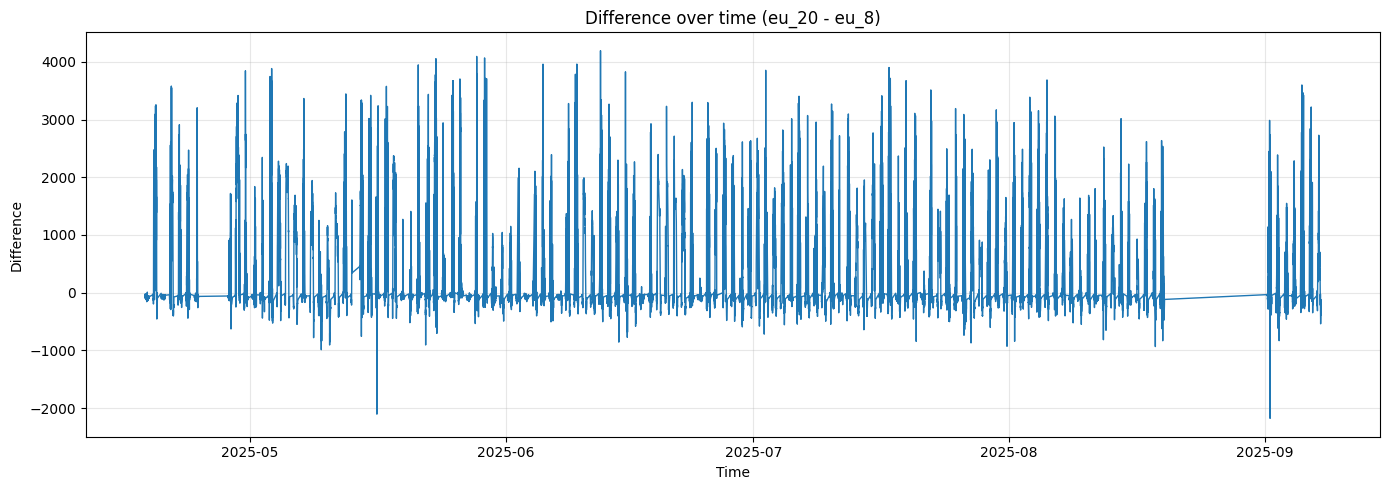

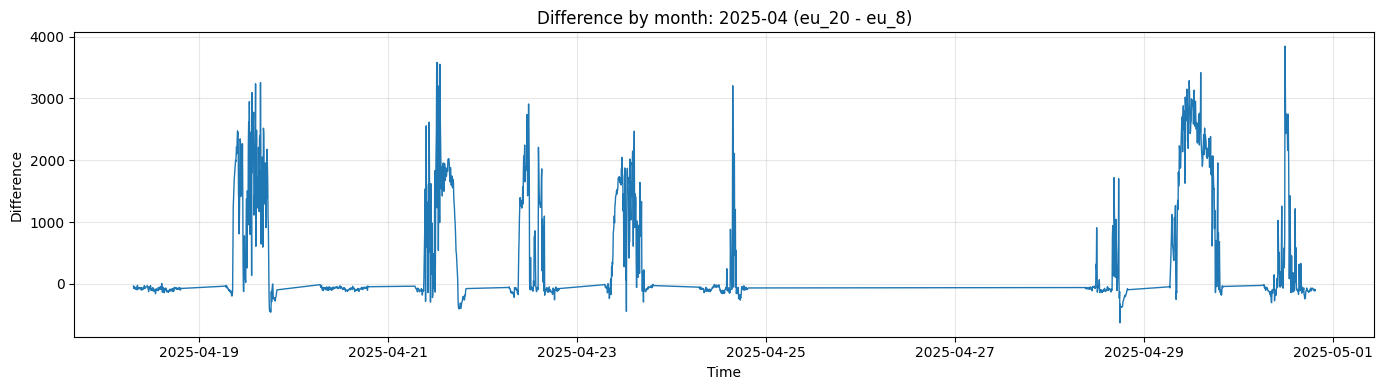

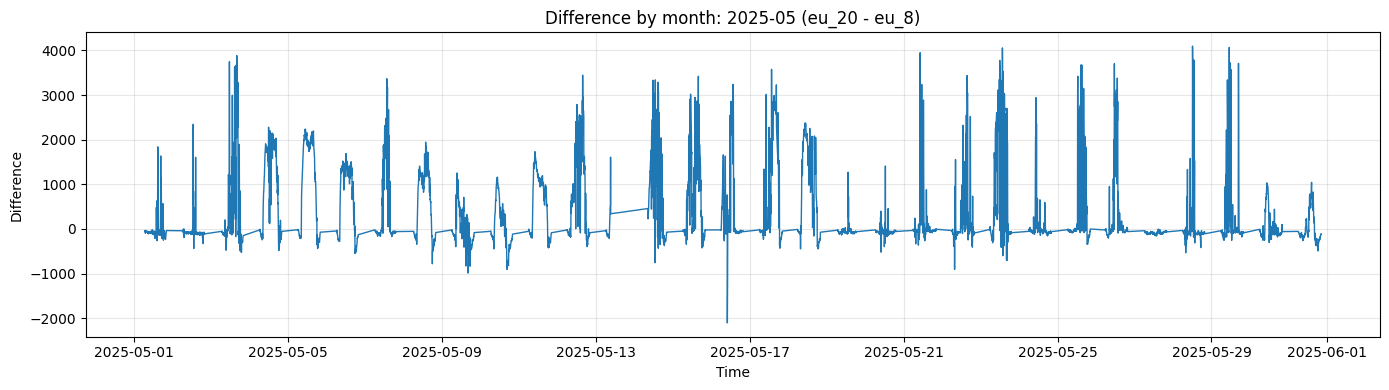

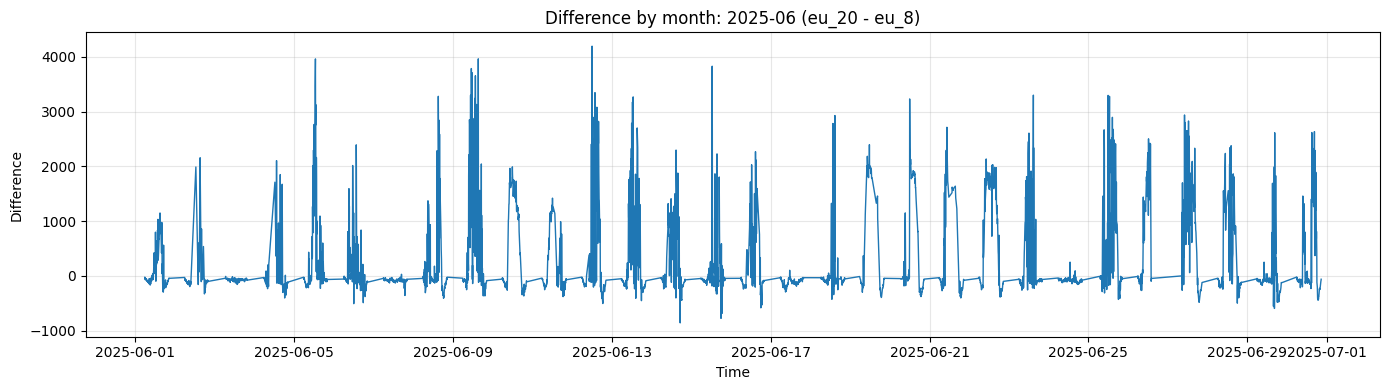

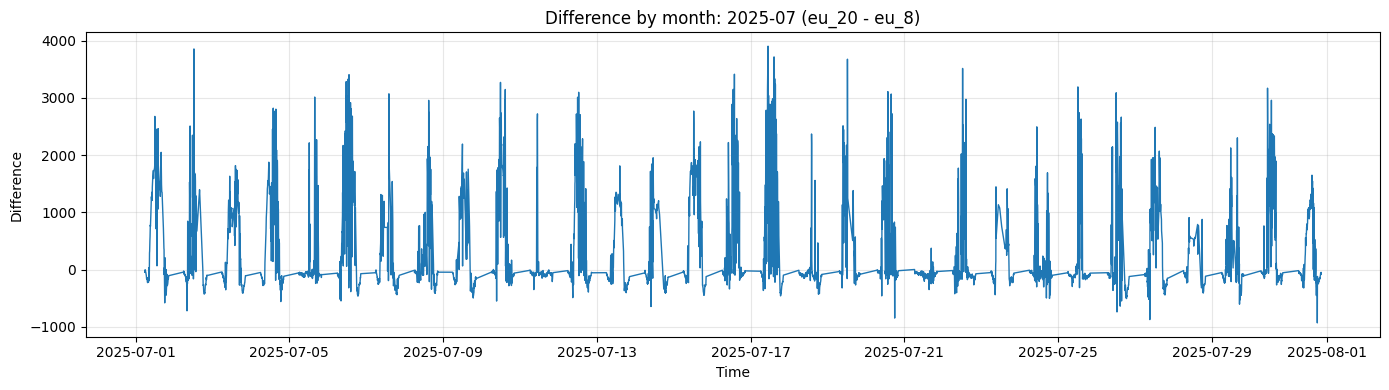

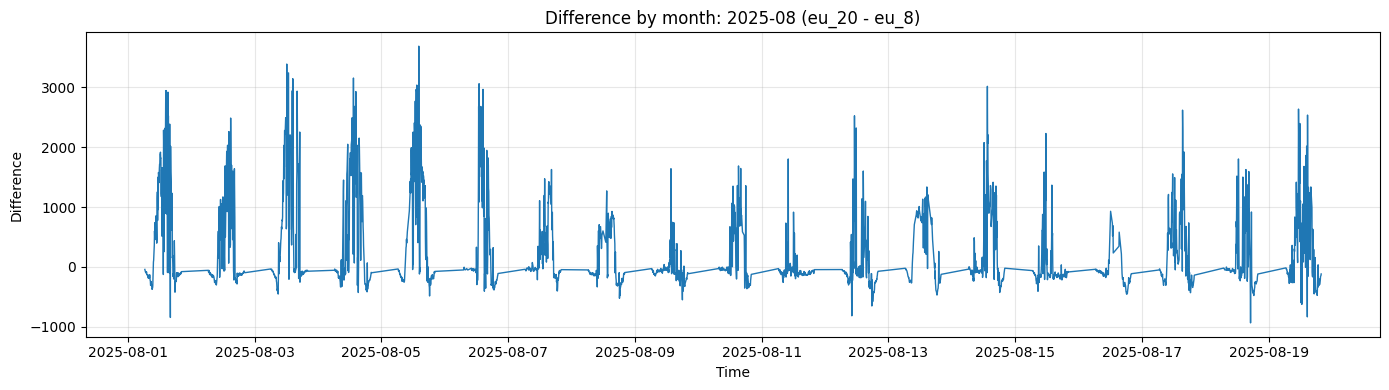

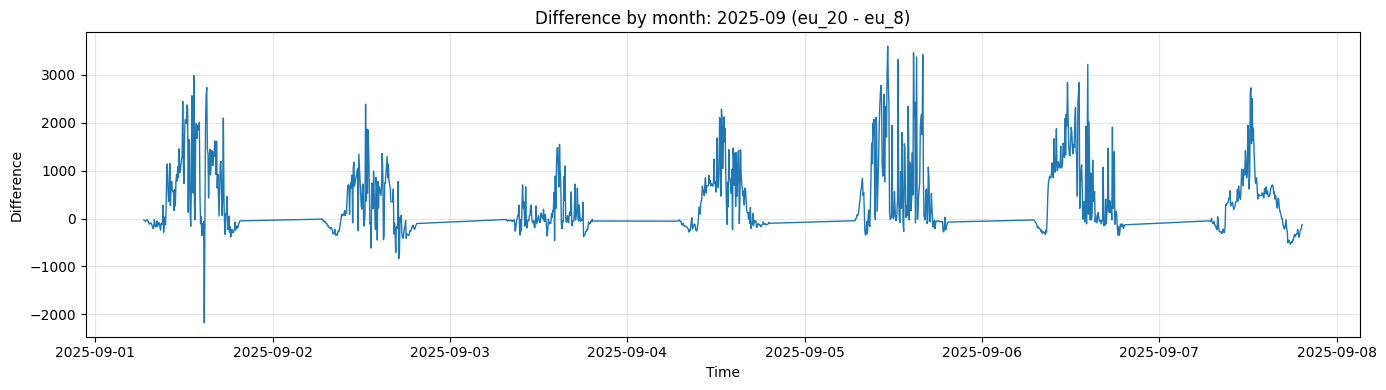

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Work only with the columns we care about and ensure proper time dtype
pair_df = combined_df[["time", "eu_8", "eu_20"]].copy()
pair_df["time"] = pd.to_datetime(pair_df["time"])

# Keep only rows where both eu_8 and eu_20 are non-zero
non_zero_mask = (pair_df["eu_8"] != 0) & (pair_df["eu_20"] != 0)
clean_df = pair_df[non_zero_mask].copy()

# Compute power difference (eu_20 - eu_8)
clean_df["diff"] = clean_df["eu_20"] - clean_df["eu_8"]

print("Total non-zero rows considered:", len(clean_df))

# ---- Overall statistics of difference ----
overall_stats = clean_df["diff"].describe()
print("\nOverall statistics for diff (eu_20 - eu_8):")
print(overall_stats)
print("Median:", clean_df["diff"].median())
print("Variance:", clean_df["diff"].var())
print("IQR:", clean_df["diff"].quantile(0.75) - clean_df["diff"].quantile(0.25))

# ---- Monthly statistics of difference ----
clean_df["month"] = clean_df["time"].dt.to_period("M")
monthly_stats = clean_df.groupby("month")["diff"].agg(
    count="count",
    mean="mean",
    std="std",
    min="min",
    q25=lambda s: s.quantile(0.25),
    median="median",
    q75=lambda s: s.quantile(0.75),
    max="max"
)
monthly_stats["iqr"] = monthly_stats["q75"] - monthly_stats["q25"]

print("\nMonthly statistics for diff (eu_20 - eu_8):")
print(monthly_stats)

# ---- Plot difference over time ----
plt.figure(figsize=(14, 5))
plt.plot(clean_df["time"], clean_df["diff"], linewidth=1)
plt.title("Difference over time (eu_20 - eu_8)")
plt.xlabel("Time")
plt.ylabel("Difference")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Plot difference for each month ----
monthly_groups = clean_df.groupby("month")

for month, month_df in monthly_groups:
    plt.figure(figsize=(14, 4))
    plt.plot(month_df["time"], month_df["diff"], linewidth=1)
    plt.title(f"Difference by month: {month} (eu_20 - eu_8)")
    plt.xlabel("Time")
    plt.ylabel("Difference")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



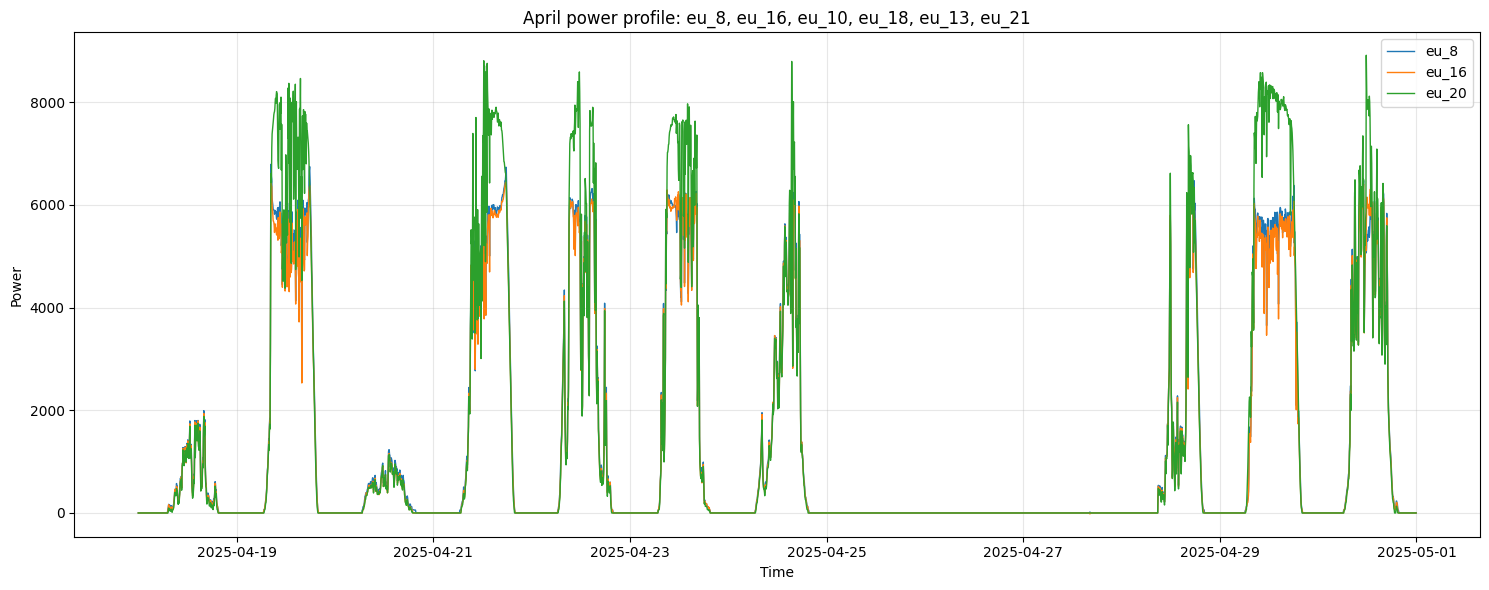

In [12]:
# ---- One plot for April: eu_8, eu_16, eu_10, eu_18, eu_13, eu_21 ----
plot_cols = ["eu_8", "eu_16", "eu_20"]

april_df = combined_df[["time"] + plot_cols].copy()
april_df["time"] = pd.to_datetime(april_df["time"])
april_df = april_df[april_df["time"].dt.month == 4].sort_values("time")

plt.figure(figsize=(15, 6))
for col in plot_cols:
    plt.plot(april_df["time"], april_df[col], linewidth=1, label=col)

plt.title("April power profile: eu_8, eu_16, eu_10, eu_18, eu_13, eu_21")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# Create a new CSV with a saturation flag based on mean comparisons
single_cols = [
    "eu_1",
    "eu_2",
    "eu_3",
    "eu_9",
    "eu_11",
    "eu_17",
    "eu_19",
]
shared_cols = ["eu_8", "eu_10", "eu_16", "eu_18"]

saturated_df = combined_df.copy()

mean_single = saturated_df[single_cols].mean(axis=1)
mean_shared = saturated_df[shared_cols].mean(axis=1)

saturated_df["saturated"] = (mean_single > (mean_shared + 300)).astype(int)

output_path = "combined_apr_sep_2025_area1_with_saturated.csv"
saturated_df.to_csv(output_path, index=False)

print(f"Saved: {output_path}")

preview_cols = ["time"] + single_cols + shared_cols + ["saturated"]
saturated_df[preview_cols].head()

Saved: combined_apr_sep_2025_area1_with_saturated.csv


,time,eu_1,eu_2,eu_3,eu_9,eu_11,eu_17,eu_19,eu_8,eu_10,eu_16,eu_18,saturated
0,2025-04-18 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2025-04-18 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2025-04-18 00:10:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2025-04-18 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2025-04-18 00:20:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
